In [1]:
import os
import random
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetHead
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torchvision.models.detection._utils import Matcher

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch

def evaluate_map(model, data_loader, device):
    model.eval()

    metric = MeanAveragePrecision(
        iou_type="bbox",
        iou_thresholds=None,  # default: 0.5:0.95 step 0.05
        class_metrics=False
    )

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            preds = []
            gts = []

            for output, target in zip(outputs, targets):
                preds.append({
                    "boxes": output["boxes"].detach().cpu(),
                    "scores": output["scores"].detach().cpu(),
                    "labels": output["labels"].detach().cpu(),
                })

                gts.append({
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu(),
                })

            metric.update(preds, gts)

    results = metric.compute()

    return {
        "mAP": results["map"].item(),        # AP @[.5:.95]
        "mAP_50": results["map_50"].item(),  # AP @ .50
        "mAP_75": results["map_75"].item(),  # AP @ .75
    }

def evaluate_precision_recall(model, data_loader, device, iou_thresh=0.5):
    model.eval()

    thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98]
    stats = {t: {"TP": 0, "FP": 0, "FN": 0} for t in thresholds}

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):

                pred_boxes = output["boxes"].detach().cpu()
                pred_scores = output["scores"].detach().cpu()
                pred_labels = output["labels"].detach().cpu()

                gt_boxes = target["boxes"].detach().cpu()
                gt_labels = target["labels"].detach().cpu()

                for t in thresholds:

                    keep = pred_scores >= t
                    boxes = pred_boxes[keep]
                    labels = pred_labels[keep]

                    matched_gt = set()

                    if len(boxes) > 0 and len(gt_boxes) > 0:
                        ious = box_iou(boxes, gt_boxes)

                        for i in range(len(boxes)):
                            max_iou, gt_idx = ious[i].max(0)

                            if (
                                max_iou >= iou_thresh
                                and gt_idx.item() not in matched_gt
                                and labels[i] == gt_labels[gt_idx]
                            ):
                                stats[t]["TP"] += 1
                                matched_gt.add(gt_idx.item())
                            else:
                                stats[t]["FP"] += 1
                    else:
                        stats[t]["FP"] += len(boxes)

                    stats[t]["FN"] += len(gt_boxes) - len(matched_gt)

    results = {}

    for t in thresholds:
        TP = stats[t]["TP"]
        FP = stats[t]["FP"]
        FN = stats[t]["FN"]

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

        results[round(float(t), 2)] = {
            "precision": precision,
            "recall": recall
        }

    return results

In [3]:
# -----------------------------
# Configuration
# -----------------------------
CSV_FILE = "MDAD_trimmed_retinanet.csv"
IMAGE_DIR = "marci_seen"

BATCH_SIZE = 8
EPOCHS = 400
LR = 2e-4
VAL_SPLIT = 0.1
SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_DIR = "checkpoints_rcnn_5band"
METRICS_CSV = "training_metrics_rcnn_5band.csv"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
random.seed(SEED)

### Simple Loading of Train/Test Data (No Augmentations)

In [ ]:
# -----------------------------
# Load and clean CSV
# -----------------------------
df = pd.read_csv(CSV_FILE)

df["image_path"] = df["filename"].apply(lambda x: os.path.join(IMAGE_DIR, x))
df = df[df["image_path"].apply(os.path.exists)]

df = df[
    (df["xmax"] > df["xmin"]) &
    (df["ymax"] > df["ymin"])
]

grouped = list(df.groupby("image_path"))
random.shuffle(grouped)

print("Total rows in CSV:", len(df))
print("Unique images after filtering:", len(grouped))
print("VAL_SPLIT:", VAL_SPLIT)

split_idx = int(len(grouped) * (1 - VAL_SPLIT))
print("split_idx:", split_idx)

train_items = grouped[:split_idx]
val_items = grouped[split_idx:]

print("Train items:", len(train_items))
print("Val items:", len(val_items))

# -----------------------------
# Dataset
# -----------------------------
class CSVDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        image_path, boxes_df = self.items[idx]
    
        image = Image.open(image_path).convert("RGB")
        image = F.to_tensor(image)
    
        boxes = boxes_df[["xmin", "ymin", "xmax", "ymax"]].values
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
    
        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)
    
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
    
        image_id = torch.tensor(idx)  # ✅ FIXED
    
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": torch.zeros((boxes.shape[0],), dtype=torch.int64),
        }
    
        return image, target



def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = CSVDataset(train_items)
val_dataset = CSVDataset(val_items)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

### Train/Test Loader with Data Augmentation

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

from collections import defaultdict

# -----------------------------
# 1. Define Augmentations
# -----------------------------
def get_train_transforms():
    return A.Compose([
        # Geometric (Affects boxes)
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        # Random Crop (preserves boxes, removes those that fall outside)
        A.RandomSizedBBoxSafeCrop(height=600, width=600, p=0.5),
        
        # Color/Pixel (Does not affect boxes)
        A.RandomBrightnessContrast(p=0.2),
        
        # Normalization (Standard for pre-trained ResNets)
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2() # Converts to PyTorch Tensor [C, H, W]
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

def get_val_transforms():
    return A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

# -----------------------------
# Load CSV
# -----------------------------
df = pd.read_csv(CSV_FILE)

# Remove invalid boxes
df = df[
    (df["xmax"] > df["xmin"]) &
    (df["ymax"] > df["ymin"])
]

# -----------------------------
# Group bounding boxes by filename
# -----------------------------
bbox_dict = defaultdict(list)

for _, row in df.iterrows():
    bbox = [
        row["xmin"],
        row["ymin"],
        row["xmax"],
        row["ymax"]
    ]
    bbox_dict[row["filename"]].append(bbox)

# -----------------------------
# Collect ALL images from all bands
# -----------------------------
band_dirs = [f"band{i}" for i in range(1, 6)]

dataset_entries = []

for band in band_dirs:
    band_path = os.path.join(IMAGE_DIR, band)
    
    if not os.path.isdir(band_path):
        continue
        
    for filename in os.listdir(band_path):
        image_path = os.path.join(band_path, filename)

        if os.path.isdir(image_path):
            continue

        boxes = bbox_dict.get(filename, [])  # empty list if none
        
        dataset_entries.append({
            "image_path": image_path,
            "boxes": boxes,
            "band": band
        })

print("Total images:", len(dataset_entries))
print("VAL_SPLIT:", VAL_SPLIT)

# Shuffle once before splitting
random.shuffle(dataset_entries)

split_idx = int(len(dataset_entries) * (1 - VAL_SPLIT))
train_items = dataset_entries[:split_idx]
val_items = dataset_entries[split_idx:]

print(f"Train images: {len(train_items)}")
print(f"Val images: {len(val_items)}")

Total images: 13502
VAL_SPLIT: 0.1
Train images: 12151
Val images: 1351


In [5]:
# -----------------------------
# Updated Dataset
# -----------------------------
class CSVDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        entry = self.items[idx]

        image_path = entry["image_path"]
        boxes = entry["boxes"]  # already list of lists

        # 1. Load Image
        image = np.array(Image.open(image_path).convert("RGB"))

        # 2. Convert boxes to numpy array
        if len(boxes) > 0:
            boxes = np.array(boxes, dtype=np.float32)
            labels = np.ones((boxes.shape[0],), dtype=np.int64)
        else:
            boxes = np.zeros((0, 4), dtype=np.float32)
            labels = np.zeros((0,), dtype=np.int64)

        # 3. Apply Augmentations
        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                labels=labels
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["labels"]

        # 4. Convert to tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }

        return image, target
        
def collate_fn(batch):
    return tuple(zip(*batch))

In [6]:
# -----------------------------
# Initialize with Transforms
# -----------------------------
train_dataset = CSVDataset(train_items, transform=get_train_transforms())
val_dataset = CSVDataset(val_items, transform=get_val_transforms())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,  # Recommended to speed up augmentations
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print(len(train_loader))
print(len(val_loader))

1519
169


### Evaluate Train/Test Dataset

In [17]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

checkpoint_path = "checkpoints_rcnn_5band/rcnn_epoch_235.pth"
num_classes = 2 

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
# -----------------------------
# Model
# -----------------------------
# 1. Create base model WITHOUT pretrained COCO weights
model = fasterrcnn_resnet50_fpn(weights=None)

# 2. Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# 3. Load trained weights
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

evaluate_precision_recall(model, train_loader, DEVICE)
#evaluate_precision_recall(model, val_loader, DEVICE)

{0.2: {'precision': 0.18199492291498978, 'recall': 0.5939861779089035},
 0.3: {'precision': 0.2616596945228135, 'recall': 0.5435072545770521},
 0.4: {'precision': 0.34311267134737544, 'recall': 0.4977165258861092},
 0.5: {'precision': 0.4298179059180577, 'recall': 0.45790728690942895},
 0.6: {'precision': 0.5225910441746839, 'recall': 0.4193105120640181},
 0.7: {'precision': 0.6203666532851599, 'recall': 0.37473224750434464},
 0.8: {'precision': 0.7311211757094002, 'recall': 0.3196863759447116},
 0.9: {'precision': 0.854645282473631, 'recall': 0.23905751121529323},
 0.95: {'precision': 0.9292132369055446, 'recall': 0.1713615972194156},
 0.98: {'precision': 0.9798305768455022, 'recall': 0.09816917916178312}}

### RCNN Model Train from Scratch

In [6]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# -----------------------------
# Configuration
# -----------------------------
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
num_classes = 2  # 1 class (object) + 1 background

# -----------------------------
# Model
# -----------------------------
# 1. Load the pre-trained Faster R-CNN model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

# 2. Replace the classification head (Box Predictor)
# Unlike RetinaNet, we modify the 'roi_heads.box_predictor'
# Get the number of input features for the classifier (usually 1024 for ResNet50)
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(DEVICE)

# -----------------------------
# Optimizer
# -----------------------------
# SGD is typically preferred for Faster R-CNN
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=0.9,
    weight_decay=0.0005
)

### RCNN Model Continue Training

In [7]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

checkpoint_path = "checkpoints_rcnn_5band/rcnn_epoch_344.pth"
num_classes = 2 

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
# -----------------------------
# Model
# -----------------------------
# 1. Create base model WITHOUT pretrained COCO weights
model = fasterrcnn_resnet50_fpn(weights=None)

# 2. Replace the classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# 3. Load trained weights
model.load_state_dict(checkpoint["model_state_dict"])

model.to(DEVICE)
model.train()   # Important: Set back to training mode

# -----------------------------
# Optimizer
# -----------------------------
# SGD is typically preferred for Faster R-CNN
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

In [ ]:
import time
import numpy as np

# -----------------------------
# Metrics logging
# -----------------------------
metrics = []

# -----------------------------
# Training + Validation loop
# -----------------------------
for epoch in range(345, EPOCHS + 1):
    epoch_time = time.time() # Fixed: time.time() at start
    
    model.train()
    train_loss = 0.0
    for images, targets in train_loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True) # More efficient than zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Memory Clean Up ---
    del images, targets
    torch.cuda.empty_cache()

    # ---- Validation ----
    model.train() # Keeping train() for loss calculation
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            val_loss += sum(loss_dict.values()).item()

    # --- Memory Clean Up Before mAP ---
    del images, targets
    torch.cuda.empty_cache()

    model.eval() 
    val_map = evaluate_map(model, val_loader, DEVICE)
    
    # ... (Rest of your logging code)
    
    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    
        "val_mAP": val_map["mAP"],
        "val_mAP_50": val_map["mAP_50"],
        "val_mAP_75": val_map["mAP_75"],
    
        "epoch_time_sec": epoch_time,
    }
    
    metrics.append(epoch_metrics)
    pd.DataFrame(metrics).to_csv(METRICS_CSV, index=False)

    # ---- Save checkpoint ----
    checkpoint_path = os.path.join(
        CHECKPOINT_DIR, f"rcnn_epoch_{epoch:02d}.pth"
    )

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        checkpoint_path,
    )

    print(
        f"Epoch [{epoch}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Time: {epoch_time:.2f}s ({epoch_time/60:.2f} min)"
    )

print("Training complete.")

### Visualise bounding boxes on dust storms

In [9]:
# Cell 2: User inputs
weights_path = "checkpoints_rcnn_5band/rcnn_epoch_290.pth"     # path to your.pth
image_path   = "marci_unseen/band3/J02_day23_band0003_resx2.tiff"      # path to the image you want to evaluate
num_classes  = 2                              # set to the number of classes you trained on
class_names  = None                           # e.g., ["cat", "dog", "car"] or None to auto-generate
classes_txt  = None                           # optional: "classes.txt" (one name per line); overrides class_names when provided
score_thr    = 0.1                           # confidence threshold for showing boxes

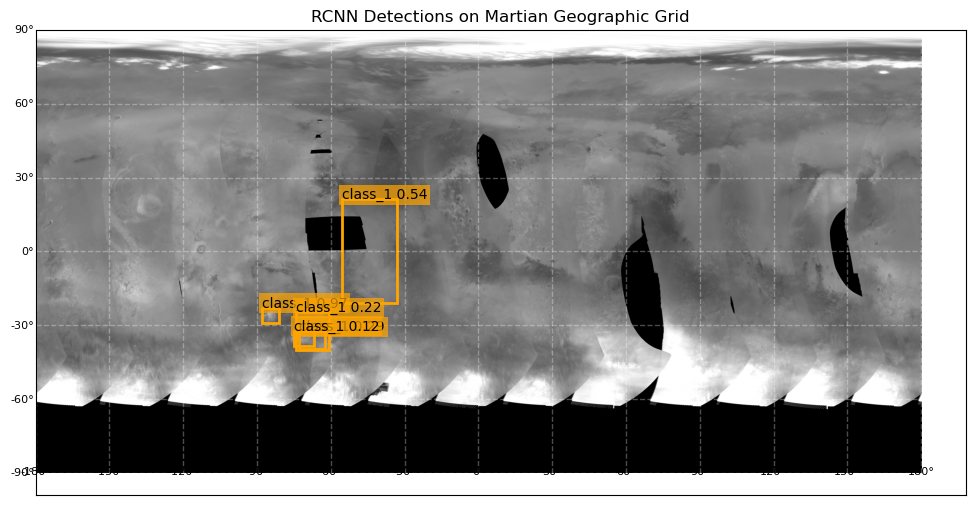

In [10]:
# Cell 1: Imports
import torch
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def build_model(num_classes: int):
    # Create a RetinaNet with ResNet-50 FPN backbone (torchvision)
    # Use weights=None since we'll load your custom training weights.
    model = fasterrcnn_resnet50_fpn(weights=None, num_classes=num_classes)
    return model

def _strip_prefix(k: str):
    for p in ("module.", "model.", "net."):
        if k.startswith(p):
            return k[len(p):]
    return k

def load_weights_flex(model: torch.nn.Module, ckpt_path: str, device: torch.device):
    ckpt = torch.load(ckpt_path, map_location=device)
    # Try common dict formats
    state = None
    if isinstance(ckpt, dict):
        if "model_state_dict" in ckpt:
            state = ckpt["model_state_dict"]
        elif "state_dict" in ckpt:
            state = ckpt["state_dict"]
        elif all(isinstance(v, torch.Tensor) for v in ckpt.values()):
            state = ckpt
    if state is not None:
        target_sd = model.state_dict()
        cleaned = {}
        for k, v in state.items():
            nk = _strip_prefix(k)
            if nk in target_sd and v.shape == target_sd[nk].shape:
                cleaned[nk] = v
            else:
                # allow non-strict load; mismatched heads will be skipped
                pass
        model.load_state_dict(cleaned, strict=False)
        return model

    # Fallback: checkpoint might be a full model object (torch.save(model))
    if hasattr(ckpt, "state_dict"):
        try:
            model.load_state_dict(ckpt.state_dict(), strict=False)
            return model
        except Exception:
            pass
    # If it's already a model, just return it
    if isinstance(ckpt, torch.nn.Module):
        ckpt.to(device)
        return ckpt

    raise RuntimeError("Unrecognized checkpoint format. Provide a plain state_dict or a saved model.")

def load_class_names(class_names, classes_txt, num_classes):
    if classes_txt:
        with open(classes_txt, "r", encoding="utf-8") as f:
            names = [ln.strip() for ln in f if ln.strip()]
        return names
    if class_names:
        return class_names
    return [f"class_{i}" for i in range(num_classes)]

# Cell 4: Load model, run inference on the image, and visualize

# Build and load model
model = build_model(num_classes=num_classes).to(device)
model = load_weights_flex(model, weights_path, device)
model.eval()

# Load image
img = Image.open(image_path).convert("RGB")
img_tensor = F.to_tensor(img).to(device)  # [C,H,W], float32 in [0,1]

with torch.no_grad():
    out = model([img_tensor])[0]  # dict: boxes [N,4], labels [N], scores [N]

boxes  = out.get("boxes", torch.empty((0, 4))).cpu().numpy()
labels = out.get("labels", torch.empty((0,), dtype=torch.long)).cpu().numpy()
scores = out.get("scores", torch.empty((0,))).cpu().numpy()

cls_names = load_class_names(class_names, classes_txt, num_classes)

# 1. Get image dimensions from the tensor
# img_tensor.shape is [C, H, W]
_, h, w = img_tensor.shape

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)

# --- GRIDLINE LOGIC START ---
# Define intervals (e.g., every 30 degrees)
lon_ticks = np.arange(-180, 181, 30)
lat_ticks = np.arange(-90, 91, 30)

# Draw Longitude lines (Vertical)
for lon in lon_ticks:
    # Map -180...180 to 0...w
    x = ((lon + 180) / 360) * w
    ax.axvline(x, color='white', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(x, h + 15, f"{lon}°", color='black', fontsize=8, ha='center')

# Draw Latitude lines (Horizontal)
for lat in lat_ticks:
    # Map 90...-90 to 0...h (Note: 90N is y=0 in image coords)
    y = ((90 - lat) / 180) * h
    ax.axhline(y, color='white', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(-15, y, f"{lat}°", color='black', fontsize=8, va='center', ha='right')
# --- GRIDLINE LOGIC END ---

# Your existing detection loop
for box, lab, sc in zip(boxes, labels, scores):
    if sc < score_thr:
        continue
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             linewidth=2, edgecolor="orange", facecolor="none")
    ax.add_patch(rect)
    name = cls_names[lab] if lab < len(cls_names) else str(lab)
    ax.text(x1, y1 - 5, f"{name} {sc:.2f}",
            color="black", fontsize=10,
            bbox=dict(facecolor="orange", alpha=0.7, edgecolor="none", pad=2))

# Re-enable ticks slightly or keep off and rely on manual text
ax.axis("on") 
ax.set_xticks([]) # Hide pixel ticks
ax.set_yticks([]) 
plt.title("RCNN Detections on Martian Geographic Grid")
plt.show()

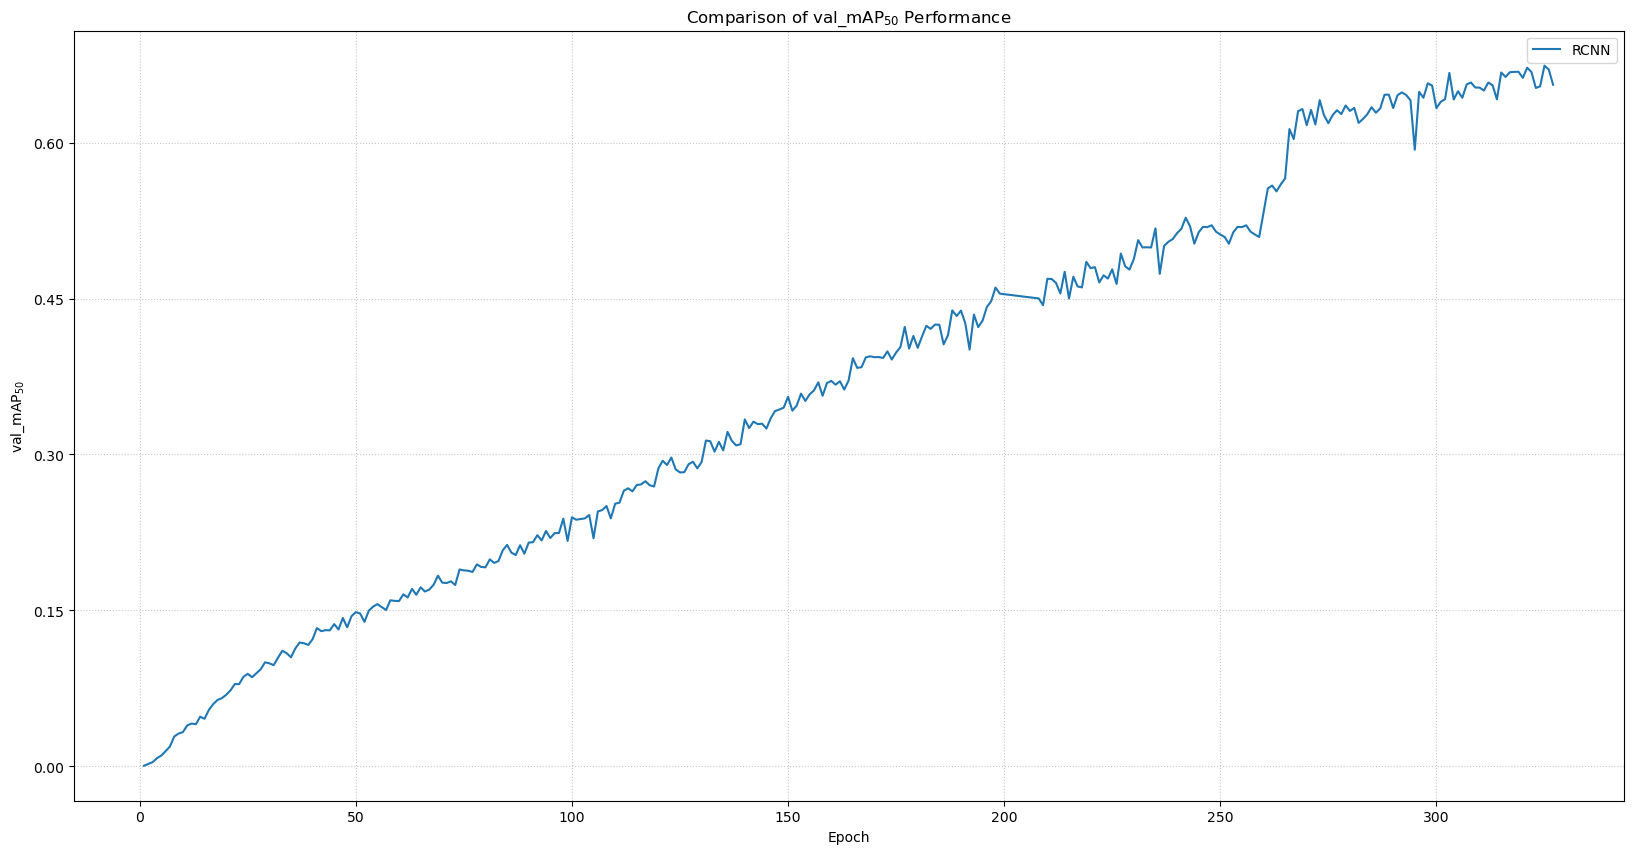

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # 1. Import ticker
import pandas as pd

plt.rcParams["figure.figsize"] = (20, 10)

try:
    df_rcnn = pd.read_csv('checkpoints_rcnn_5band/training_metrics_rcnn_5band.csv')

    df_rcnn['epoch'] = pd.to_numeric(df_rcnn['epoch'], errors='coerce')
    df_rcnn['val_mAP_50'] = pd.to_numeric(df_rcnn['val_mAP_50'], errors='coerce')

    # Drop any rows that became NaN so the line connects cleanly
    df_rcnn = df_rcnn.dropna(subset=['epoch', 'val_mAP_50'])

    if 'val_mAP_50' in df_rcnn.columns:
        plt.plot(df_rcnn['epoch'], df_rcnn['val_mAP_50'], label='RCNN')

    plt.title(r'Comparison of $\text{val\_mAP}_{50}$ Performance')
    plt.xlabel('Epoch')
    plt.ylabel(r'$\text{val\_mAP}_{50}$')
    
    # 2. Clean up the y-axis so it doesn't show every single value
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")